In [1]:
import sys
sys.path.append('../')
import numpy as np
import qutip as qt
import pandas as pd
import scipy as sp
import matplotlib.pyplot as plt
from IPython.display import display
from tqdm import tqdm

from multiprocessing import Pool

import utils_2Q_gate_zp as ut
from X_gate_fidelity_optimize import get_propagator, get_fidelity_super_operator, drive_gauss_A, drive_gauss_B, xgate_fidelity_log, xgate_fidelity_log_noise, print_soln, xgate_fidelity_parallel, truncate_2
from truncation_estimate import make_leakage_df, trunc_by_graph_estimate, make_rate_graph, shortest_path_to_core, trunc_by_thresh, all_path_to_core

In [2]:
drive_phi, drive_theta, truc = False, True, 100
# drive_phi, drive_theta, truc = True, False, 30
parallel = False
folder = 'data/data_xgate_theta_3ncut.txt' if drive_theta else 'data/data_xgate_phi.txt'
f_xgate = pd.read_csv(folder)
params = f_xgate[['tg', 'drive_amp_1', 'drive_amp_2', 'detune_1', 'detune_2']].to_numpy()
n_cpu, n_job = 4, len(params)
logi_state = [0, 2]
# [H0, drive_term, w_trans_1, w_trans_2, _] = ut.zero_pi_initialize(drive_phi, drive_theta, truncation=truc)
folder = f'data/data_one_zeropi_truncation=1000/'
trunc = 500
evals = 2*np.pi* pd.read_csv(folder+ 'evals.txt').to_numpy().flatten()[:trunc]
n_theta = 2*np.pi* pd.read_csv(folder+ 'n_theta.txt').to_numpy()[:trunc, :trunc]
n_phi = 2*np.pi* pd.read_csv(folder+ 'n_phi.txt').map(complex).to_numpy()[:trunc, :trunc]
gate_target = qt.sigmax()
gamma2 =  1 / 1600e3
# gammas =  1 / 2e3
gammas = 1 / 5e3
gamma2_p = 0 / 100e3
# ratio = 10
# gammas =  gamma_2 * ratio
# gammas_p = 1 / 9000
gammas_p = 1 / 5e3

jump_t1   = []
jump_tphi = []
gamma_t1   = [0, gammas,  gamma2]  + [gammas]  * (truc-3)
gamma_tphi = [0, gammas_p, gamma2_p] + [gammas_p] * (truc-3)
for i in range(1,truc):
    jump_t1.append( np.sqrt(gamma_t1[i]) * qt.basis(truc,0) * qt.basis(truc,i).dag() )
    jump_tphi.append( np.sqrt(2*gamma_tphi[i]) * qt.basis(truc,i).proj() )

H0 = qt.Qobj(np.diag(evals))
if drive_phi:
    w_trans_1 = evals[9] - evals[0]
    w_trans_2 = evals[9] - evals[2]
    drive_term = n_phi
if drive_theta:
    w_trans_1 = evals[7] - evals[0]
    w_trans_2 = evals[7] - evals[2]
    drive_term = n_theta
hilbert_space = np.arange(truc).tolist()
H0_truc = truncate_2(H0, hilbert_space)
drive_truc = truncate_2(drive_term, hilbert_space)
H_qbt_drive = [H0_truc, [drive_truc, drive_gauss_A],
                        [drive_truc, drive_gauss_B],]
print('drive_phi=', drive_phi, '; drive_theta = ', drive_theta, '; truc = ', truc)
print('parallel = ', parallel)
print('params =')
for para in params:
    print(para.tolist(), ',')
print("n_cpu = ", n_cpu, ";   n_job = ", n_job)
print("gamma_2 = ", gamma2, "gamma_p2 = ", gamma2_p)
print("gammas = ", gammas, "gammas_p = ", gammas_p)
print(f"T1_2 = {1/gamma2} ns") if gamma2 != 0 else None
print(f"T1_other = {1/gammas} ns") if gammas != 0 else None
print(f"Tphi_2 = {1/gamma2_p} ns") if gamma2_p != 0 else None
print(f"Tphi_other = {1/gammas_p} ns") if gammas_p != 0 else None

drive_phi= False ; drive_theta =  True ; truc =  100
parallel =  False
params =
[10.108462, 0.41212, 0.073451, -0.084451, -0.044706] ,
[15.074864, 0.303821, 0.065666, -0.036206, -0.016563] ,
[20.041257, 0.241329, 0.059044, -0.019402, -0.009802] ,
[25.020473, 0.180208, 0.046132, -0.003789, 0.001544] ,
[30.008342, 0.14538, 0.037985, 0.000555, 0.004004] ,
[34.999249, 0.121737, 0.032287, 0.001883, 0.004348] ,
[39.991616, 0.105045, 0.028058, 0.002171, 0.003988] ,
[45.572873, 0.091013, 0.02446, 0.002106, 0.003479] ,
[50.273181, 0.081831, 0.022089, 0.001944, 0.003051] ,
[55.267933, 0.073988, 0.020007, 0.001756, 0.002668] ,
[59.087483, 0.068953, 0.018674, 0.001617, 0.002406] ,
[64.670376, 0.062708, 0.017016, 0.001421, 0.002077] ,
[69.959457, 0.05777, 0.0157, 0.001257, 0.001811] ,
[79.950621, 0.050323, 0.013699, 0.001008, 0.001432] ,
[89.941952, 0.044576, 0.012149, 0.000826, 0.001154] ,
[99.933664, 0.040022, 0.010918, 0.000683, 0.000949] ,
[109.925465, 0.036325, 0.009915, 0.000575, 0.000792] ,


# Test the convergence of the 30 second pulse

In [3]:
p = params[7]
p

array([4.5572873e+01, 9.1013000e-02, 2.4460000e-02, 2.1060000e-03,
       3.4790000e-03])

In [4]:
args = [H0, drive_term, w_trans_1, w_trans_2, hilbert_space, n_cpu]
xgate_fidelity_parallel(p, *args)

-4.616711467217881

In [5]:
# c_op_list = jump_t1 + jump_tphi
# args_noise = [H_qbt_drive, w_trans_1, w_trans_2, n_cpu, c_op_list, logi_state, parallel, gate_target]
# xgate_fidelity_log_noise(p, *args_noise)

In [6]:
wd1 = w_trans_1+2*np.pi*p[3]
A1 = p[1]
wd2 = w_trans_2+2*np.pi*p[4]
A2 = p[2]
G = make_rate_graph(drive_term, evals, wd1, A1)

In [7]:
df1 = make_leakage_df([0, 2, 7], drive_term, evals, w_trans_1+2*np.pi*p[3], p[1])

100%|██████████| 500/500 [00:19<00:00, 25.87it/s] 


In [8]:
df2 = make_leakage_df([0, 2, 7], drive_term, evals, w_trans_2+2*np.pi*p[4], p[2])

100%|██████████| 500/500 [00:20<00:00, 24.80it/s]


In [9]:
df = pd.concat([df1, df2]).sort_values("path_len", ascending=False).drop_duplicates("i", keep="first")
df.iloc[:30]

,i,path,path_len
0,0,0,1.000000e+00
2,2,2,1.000000e+00
7,7,"2,7",4.318554e-04
1,1,"0,1",9.856333e-06
5,5,"2,5",7.090726e-06
12,12,"2,12",1.361970e-08
11,11,"2,7,11",5.620316e-09
8,8,"2,7,8",1.786168e-09
21,21,"2,21",4.626614e-10
25,25,"0,7,25",3.902626e-10


In [10]:
states_short = trunc_by_graph_estimate(500, [0, 2, 7], drive_term, evals, [wd1, wd2], [A1, A2], path_func=shortest_path_to_core)

100%|██████████| 500/500 [00:20<00:00, 24.82it/s]


In [11]:
states_short[:30] == df.iloc[:30].i.values

array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True])

In [12]:
states_all = trunc_by_graph_estimate(500, [0, 2, 7], drive_term, evals, [wd1, wd2], [A1, A2], path_func=all_path_to_core)

100%|██████████| 500/500 [02:40<00:00,  3.12it/s]


In [13]:
def test_pulse(hilbert_space):
    args = [H0, drive_term, w_trans_1, w_trans_2, hilbert_space, n_cpu]
    return xgate_fidelity_parallel(p, *args)

In [14]:
vals = []
for i in tqdm(range(500)):
    vals.append(trunc_by_thresh([0, 2, 7], drive_term, total_trunc=i))
how_many = [len(v) for v in vals]
how_many.index(100)

100%|██████████| 500/500 [00:23<00:00, 21.36it/s] 


189

In [15]:
how_many.index(80)

152

In [16]:
test_truncs = np.linspace(10, 250, 30)
fids_g_s = np.zeros_like(test_truncs)
fids_g_a = np.zeros_like(test_truncs)
fids_n = np.zeros_like(test_truncs)
fids_t = np.zeros_like(test_truncs)
for i,t in enumerate(tqdm(test_truncs)):
    t = int(t)
    by_graph_shortest = sorted(states_short[:t])
    by_graph_all = sorted(states_all[:t])
    by_n = list(np.arange(t))
    by_thresh = trunc_by_thresh([0, 2, 7], drive_term, total_trunc=how_many.index(t))
    fids_g_s[i] = test_pulse(by_graph_shortest)
    fids_g_a[i] = test_pulse(by_graph_all)
    fids_n[i] = test_pulse(by_n)
    fids_t[i] = test_pulse(by_thresh)

100%|██████████| 30/30 [19:40<00:00, 39.37s/it] 


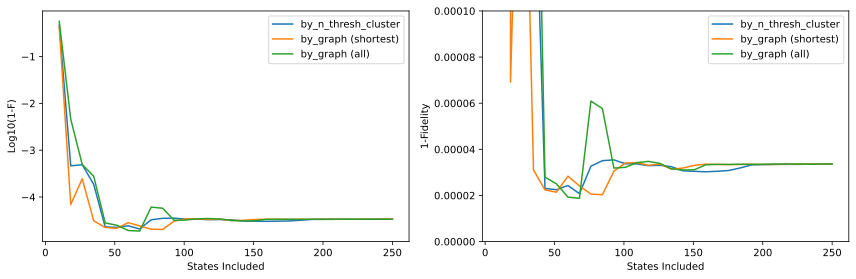

In [29]:
f, ax = plt.subplots(ncols=2, figsize=(12,4))
# ax[0].plot(test_truncs, fids_n, label="by_n");
ax[0].plot(test_truncs, fids_t, label="by_n_thresh_cluster");
ax[0].plot(test_truncs, fids_g_s, label="by_graph (shortest)");
ax[0].plot(test_truncs, fids_g_a, label="by_graph (all)");
ax[0].set_ylabel("Log10(1-F)")
ax[0].set_xlabel("States Included")
ax[0].legend();

# ax[1].plot(test_truncs, 10**(fids_n), label="by_n");
ax[1].plot(test_truncs, 10**(fids_t), label="by_n_thresh_cluster");
ax[1].plot(test_truncs, 10**(fids_g_s), label="by_graph (shortest)");
ax[1].plot(test_truncs, 10**(fids_g_a), label="by_graph (all)");
ax[1].set_ylabel("1-Fidelity")
ax[1].set_xlabel("States Included")
# ax[1].set_ylim((fids_t[-1]-0.1, fids_t[-1]+0.1))
ax[1].set_ylim(0, 0.0001)
ax[1].legend();

plt.tight_layout()

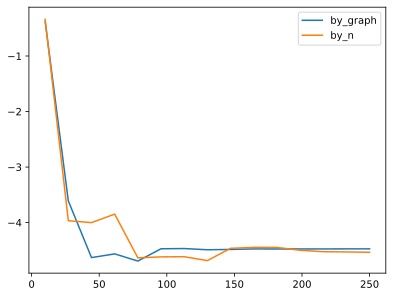

In [20]:
plt.plot(test_truncs, fids_g, label="by_graph");
plt.plot(test_truncs, fids_n, label="by_n");
plt.legend();